Columns: Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'salary'],
      dtype='str')


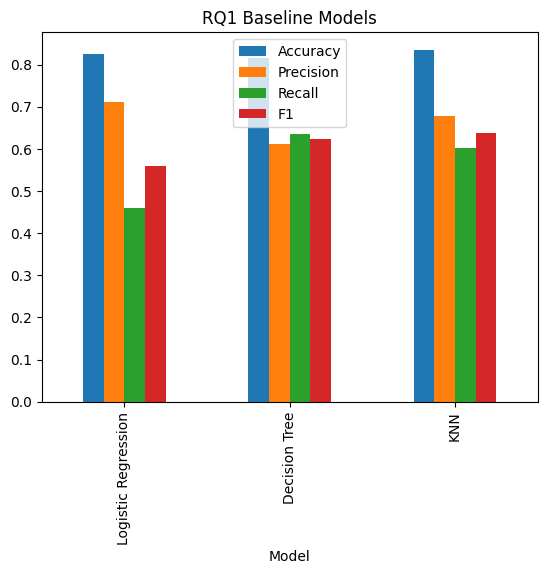

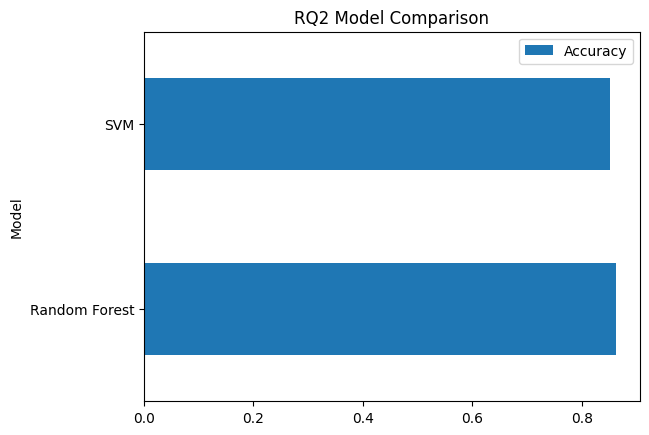

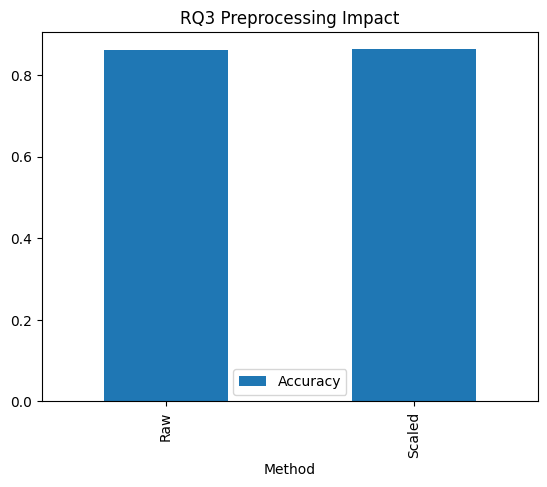

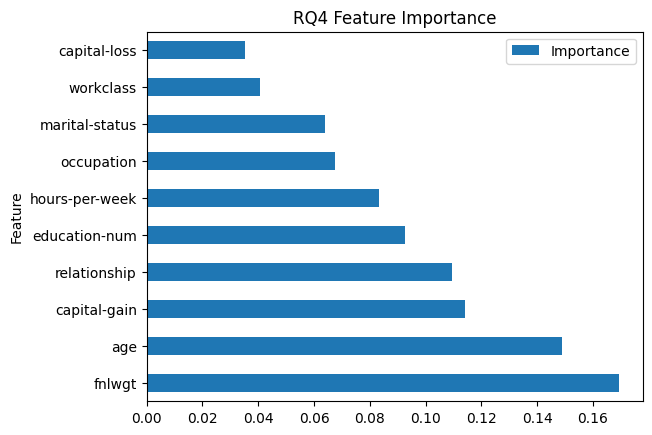

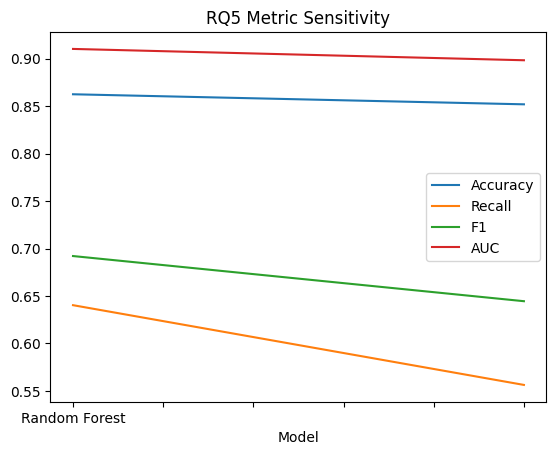

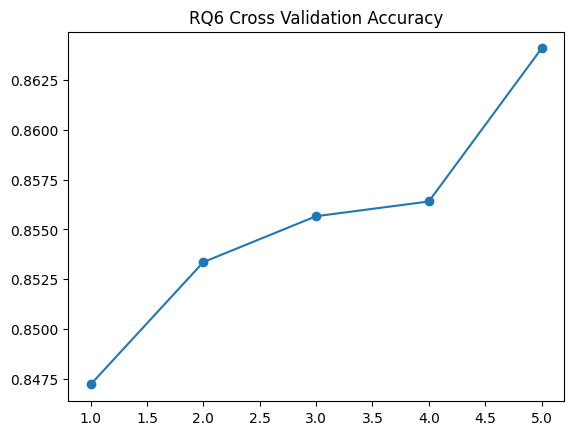

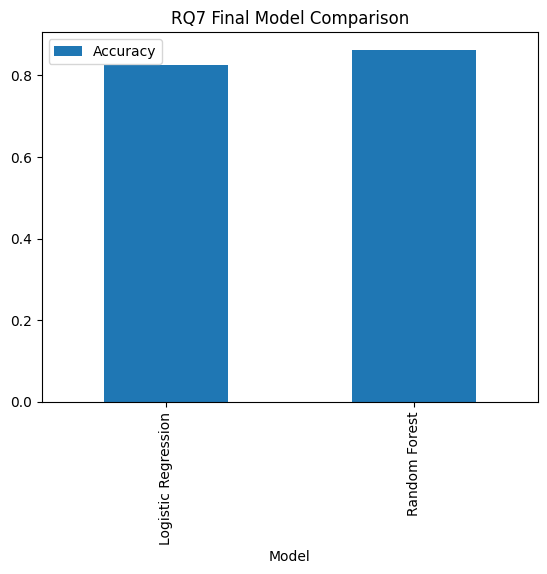

✅ ALL RQs COMPLETED SUCCESSFULLY


In [1]:
# ================================
# 0. DISPLAY SETTINGS
# ================================
%matplotlib inline

# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ================================
# 2. LOAD DATASET
# ================================
df = pd.read_csv('salary.csv')

print("Columns:", df.columns)
df = df.dropna()

# ================================
# 3. ENCODING CATEGORICAL DATA
# ================================
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ================================
# 4. SPLIT DATA
# ================================
target_column = 'salary'

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 5. SCALING
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# RQ1: BASELINE MODELS
# ================================
models_rq1 = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

rq1_results = []

for name, model in models_rq1.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    rq1_results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

rq1_df = pd.DataFrame(rq1_results,
                      columns=["Model","Accuracy","Precision","Recall","F1"])

rq1_df.to_csv("RQ1_table.csv", index=False)

rq1_df.plot(x="Model", kind="bar")
plt.title("RQ1 Baseline Models")
plt.show()

# ================================
# RQ2: ADVANCED MODELS
# ================================
models_rq2 = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

rq2_results = []

for name, model in models_rq2.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    # Safe AUC handling
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, prob)
    else:
        auc = np.nan

    rq2_results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        auc
    ])

rq2_df = pd.DataFrame(rq2_results,
                      columns=["Model","Accuracy","Precision","Recall","F1","AUC"])

rq2_df.to_csv("RQ2_table.csv", index=False)

rq2_df.plot(x="Model", y="Accuracy", kind="barh")
plt.title("RQ2 Model Comparison")
plt.show()

# ================================
# RQ3: PREPROCESSING EFFECT
# ================================
model = RandomForestClassifier()

model.fit(X_train, y_train)
pred_raw = model.predict(X_test)

model.fit(X_train_scaled, y_train)
pred_scaled = model.predict(X_test_scaled)

rq3_df = pd.DataFrame({
    "Method": ["Raw", "Scaled"],
    "Accuracy": [
        accuracy_score(y_test, pred_raw),
        accuracy_score(y_test, pred_scaled)
    ]
})

rq3_df.to_csv("RQ3_table.csv", index=False)

rq3_df.plot(x="Method", kind="bar")
plt.title("RQ3 Preprocessing Impact")
plt.show()

# ================================
# RQ4: FEATURE IMPORTANCE (FIXED)
# ================================
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

importance = model.feature_importances_

rq4_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

rq4_df.to_csv("RQ4_table.csv", index=False)

rq4_df.head(10).plot(x="Feature", y="Importance", kind="barh")
plt.title("RQ4 Feature Importance")
plt.show()

# ================================
# RQ5: METRIC SENSITIVITY
# ================================
rq5_results = []

for name, model in models_rq2.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, prob)
    else:
        auc = np.nan

    rq5_results.append([
        name,
        accuracy_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        auc
    ])

rq5_df = pd.DataFrame(rq5_results,
                      columns=["Model","Accuracy","Recall","F1","AUC"])

rq5_df.to_csv("RQ5_table.csv", index=False)

rq5_df.set_index("Model").plot()
plt.title("RQ5 Metric Sensitivity")
plt.show()

# ================================
# RQ6: CROSS VALIDATION (FIXED)
# ================================
model = RandomForestClassifier()

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

rq6_df = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_scores
})

rq6_df.to_csv("RQ6_table.csv", index=False)

plt.plot(range(1, 6), cv_scores, marker='o')
plt.title("RQ6 Cross Validation Accuracy")
plt.show()

# ================================
# RQ7: FINAL MODEL SELECTION
# ================================
final_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier()
}

rq7_results = []

for name, model in final_models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    rq7_results.append([
        name,
        accuracy_score(y_test, pred)
    ])

rq7_df = pd.DataFrame(rq7_results,
                      columns=["Model","Accuracy"])

rq7_df.to_csv("RQ7_table.csv", index=False)

rq7_df.plot(x="Model", kind="bar")
plt.title("RQ7 Final Model Comparison")
plt.show()

print("✅ ALL RQs COMPLETED SUCCESSFULLY")